# MMM — Exploratory Data Analysis
### Meridian simulated national dataset, 156 weeks

**How to use this.** Each section asks one question, renders the evidence, then
gives you prompts and reading. The conclusions go in the **Your read** cells and
they are yours — nothing here writes them for you.

Anything that becomes a *project decision* goes to `DECISIONS.md`, not here.

**Questions, in order**

| # | Question | Why it matters before modeling |
|---|---|---|
| 1 | Is the data complete and regular? | Gaps and duplicates break time-series models silently |
| 2 | What is the outcome doing? | Trend and seasonality compete with media for credit |
| 3 | How is the money split? | Sets which channels can even be meaningfully estimated |
| 4 | What does spend look like week to week? | Flighted vs always-on changes how carryover is identified |
| 5 | Is there enough variation to identify an effect? | A channel that never changes cannot be measured |
| 6 | Are the channels collinear? | Collinearity is the main reason MMMs come out unstable |
| 7 | Do the controls behave? | A control that tracks the outcome will steal media's credit |
| 8 | Is there visible carryover? | Decides whether adstock is warranted, and roughly how long |
| 9 | Is there visible diminishing returns? | The saturation curve is the deliverable — does the data show one? |
| 10 | Are spend and impressions consistent? | Unstable CPM means the two units are not interchangeable |

**Start here if you want background before the data:**
[Meridian — collecting data](https://developers.google.com/meridian/docs/user-guide/collect-data) ·
[Chan & Perry — Challenges and Opportunities in MMM](https://research.google/pubs/challenges-and-opportunities-in-media-mix-modeling/)

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

SURF, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e3e2df"
BLUE, ORANGE, AQUA, RED = "#2a78d6", "#eb6834", "#1baf7a", "#e34948"
DIVERGING = LinearSegmentedColormap.from_list("bl_rd", [BLUE, "#f0efec", RED])

plt.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "normal",
    "axes.titlelocation": "left", "figure.dpi": 110, "lines.linewidth": 2,
})

def tidy(ax, title=None, sub=None, ylab=None, pad=None):
    if title: ax.set_title(title, pad=pad or (16 if sub else 6))
    if sub:   ax.text(0, 1.015, sub, transform=ax.transAxes, fontsize=8.5, color=INK2)
    if ylab:  ax.set_ylabel(ylab)
    ax.set_axisbelow(True); ax.grid(axis="x", visible=False)
    return ax

import importlib.util
spec = importlib.util.spec_from_file_location("mmm", "../src/01_load.py")
mmm = importlib.util.module_from_spec(spec); spec.loader.exec_module(mmm)
mmm.validate()          # every integrity assertion runs before any analysis
df = mmm.national()

# --- channel labels: a DISCLOSED CONVENTION, not a finding (02-data-dictionary.md)
# Raw identifiers stay canonical everywhere; names are presentation only.
CHANNEL_NAMES = {
    "Channel0": "Programmatic display",     # evidence: weak
    "Channel1": "YouTube / premium video",  # evidence: moderate - only distinctive CPM
    "Channel2": "Out-of-home",              # evidence: moderate - bursty, dark weeks, Q4 skew
    "Channel3": "TV / CTV",                 # evidence: moderate - largest, steadiest
    "Channel4": "Paid social",              # evidence: NONE - assigned, not inferred
}
SHORT = {"Channel0": "C0 Display", "Channel1": "C1 Video", "Channel2": "C2 OOH",
         "Channel3": "C3 TV", "Channel4": "C4 Social"}
LABEL = lambda c: f"{c} · {CHANNEL_NAMES[c]}"

CH      = [f"Channel{i}" for i in range(5)]
SPEND   = [f"{c}_spend" for c in CH]
IMPR    = [f"{c}_impression" for c in CH]
CONTROL = ["competitor_sales_control", "sentiment_score_control", "Promo"]
df["revenue"] = df.conversions * df.revenue_per_conversion
df["total_spend"] = df[SPEND].sum(axis=1)

print(f"{len(df)} weeks | {df.time.min():%Y-%m-%d} to {df.time.max():%Y-%m-%d}")
df.head(3)

national : 156 weeks, 2021-01-25 to 2024-01-15
geo      : 40 geos x 156 weeks = 6240 rows
aggregation identity holds (max relative diff 2.2e-16)
paid spend 219,492,402 | revenue 1,318,718,006
all assertions passed
156 weeks | 2021-01-25 to 2024-01-15


,time,conversions,revenue_per_conversion,Channel0_impression,Channel1_impression,Channel2_impression,Channel3_impression,Channel4_impression,Channel0_spend,Channel1_spend,Channel2_spend,Channel3_spend,Channel4_spend,Organic_channel0_impression,competitor_sales_control,sentiment_score_control,Promo,revenue,total_spend
0,2021-01-25,386300926.3,0.020000,44340630,10537596,6501889,66738506,53026011,325137.56830,101595.404270,48315.04518,520082.5242,413173.984050,24028870,-0.032438,-0.342020,0.272211,7.725826e+06,1.408305e+06
1,2021-02-01,355303931.3,0.019990,47391940,30857600,7966320,79000018,27592214,347511.96809,297505.263890,59197.12148,615634.5403,214996.093200,29188267,0.312002,0.807150,0.151264,7.102386e+06,1.534845e+06
2,2021-02-08,438308889.8,0.019993,28960185,23144749,4637739,68442555,20057461,212357.01945,223143.885196,34462.68770,533361.9165,156285.964472,12051369,-1.243697,-0.152005,0.596395,8.763056e+06,1.159611e+06


> **Channel names are a labelling convention, not a finding.** The source ships
> `Channel0`-`Channel4` with no media type. Names were assigned from behavioural
> signatures; the evidence is **weak to moderate — and for `Channel4`, none at
> all**. Raw identifiers stay canonical throughout and names appear only on
> plots. **No conclusion may rest on a name.** Mapping and evidence grades:
> `02-data-dictionary.md`.

## 1. Is the data complete and regular?

In [2]:
gaps = df.time.diff().dt.days.value_counts().to_dict()
print("day-steps between rows:", gaps)
print("duplicate weeks      :", df.time.duplicated().sum())
print("missing values       :", int(df.isna().sum().sum()))
print("negative spend       :", int((df[SPEND] < 0).sum().sum()))
print("zero-conversion weeks:", int((df.conversions == 0).sum()))
print()
print(df[["conversions", "revenue_per_conversion", "total_spend"]].describe().T.to_string())

day-steps between rows: {7.0: 155}
duplicate weeks      : 0
missing values       : 0
negative spend       : 0
zero-conversion weeks: 0

                        count          mean           std           min           25%           50%           75%           max
conversions             156.0  4.226328e+08  2.921208e+07  3.402833e+08  4.053507e+08  4.227034e+08  4.404787e+08  4.912874e+08
revenue_per_conversion  156.0  2.000151e-02  1.525580e-05  1.995353e-02  1.999110e-02  2.000121e-02  2.001152e-02  2.004262e-02
total_spend             156.0  1.407003e+06  4.265735e+05  4.198948e+05  1.139011e+06  1.355441e+06  1.660606e+06  2.965465e+06


#### What to look for

- Are all the day-steps identical? A single 14-day step means a missing week that silently becomes a jump in every lag and every adstock calculation.
- Any duplicated weeks? Duplicates double-weight those observations without warning.
- Look at min/max on the outcome. Are there values extreme enough to dominate a squared-error fit?
- `revenue_per_conversion` — is it varying at all, or effectively a constant? If constant, revenue carries no information that conversions doesn't.
- Ask yourself what you would *not* be able to detect with only 156 rows. That number constrains everything downstream.

#### Reference

- [Meridian — unified data schema](https://developers.google.com/meridian/docs/user-guide/mmm-unified-schema)
- [Meridian — collecting data](https://developers.google.com/meridian/docs/user-guide/collect-data)

#### Claude's first pass — *anchors to argue with, not answers*

- Clean: 156 consecutive Monday weeks, no gaps, no duplicates, no missing values, no negative spend, no zero-conversion weeks.
- `revenue_per_conversion` does vary, but trivially — CV 0.076%. Revenue and conversions are interchangeable as an outcome.
- **156 rows is the binding constraint.** Five channels each needing a coefficient, an adstock and a saturation parameter, plus controls and seasonality, puts us near the 10:1 observations-to-parameter guideline — not comfortably above it.

**Your read:**



## 2. What is the outcome doing?

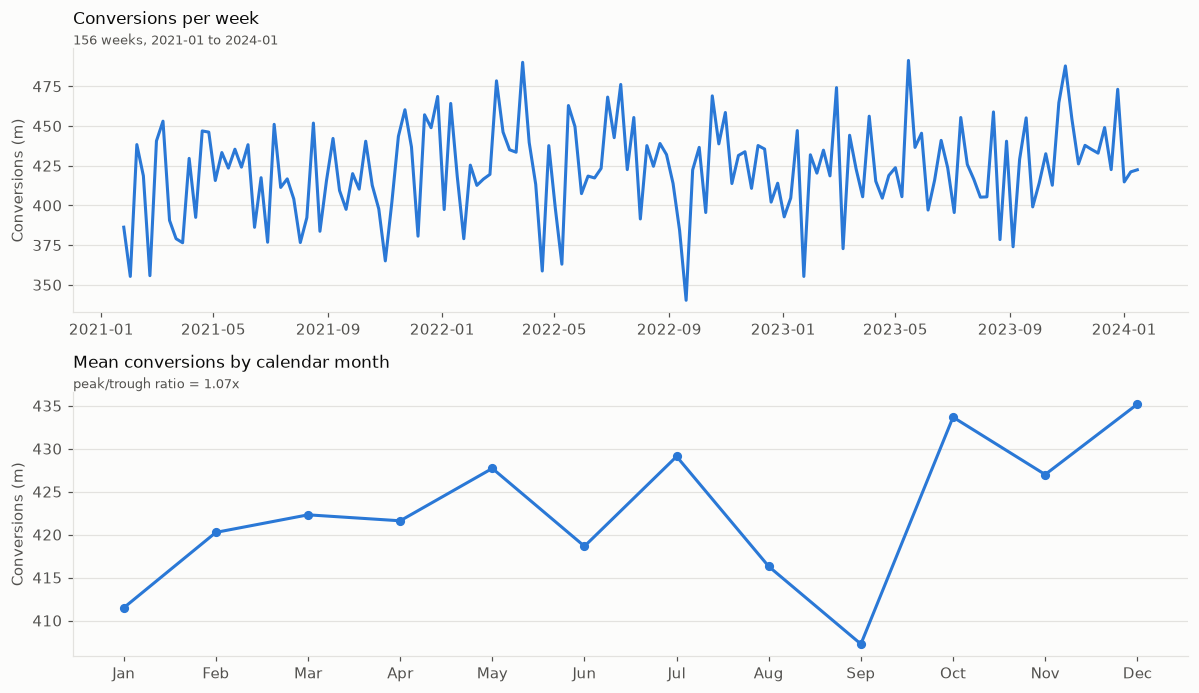

linear trend: 119,322 conversions/week (+1.5% of mean per year)


In [3]:
fig, ax = plt.subplots(2, 1, figsize=(11, 6.4))

ax[0].plot(df.time, df.conversions/1e6, color=BLUE)
tidy(ax[0], "Conversions per week", "156 weeks, 2021-01 to 2024-01", "Conversions (m)")

m = df.groupby(df.time.dt.month).conversions.mean()/1e6
ax[1].plot(m.index, m.values, color=BLUE, marker="o", markersize=5)
ax[1].set_xticks(range(1, 13))
ax[1].set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
tidy(ax[1], "Mean conversions by calendar month",
     f"peak/trough ratio = {m.max()/m.min():.2f}x", "Conversions (m)")
plt.tight_layout(); plt.show()

t = np.arange(len(df))
slope, icept = np.polyfit(t, df.conversions, 1)
print(f"linear trend: {slope:,.0f} conversions/week "
      f"({slope*52/df.conversions.mean()*100:+.1f}% of mean per year)")

#### What to look for

- Trend, flat, or stepped? A trend competes with media for credit — anything growing steadily will get attributed to whichever channel also grew.
- How strong is seasonality? Compare the peak/trough ratio to what you'd expect for a real advertiser.
- Any level shifts or structural breaks — a jump that no media plan would explain? Those usually mean something happened to the business, and the model has no way to know.
- The key question: **if you removed all media, what shape would remain?** That residual shape is the baseline the model has to find, and everything it can't explain gets dumped there.
- With only three years, how many full seasonal cycles do you actually have to learn seasonality from?

#### Reference

- [Hyndman & Athanasopoulos — Forecasting: Principles and Practice (decomposition, seasonality)](https://otexts.com/fpp3/)
- [Chan & Perry — Challenges and Opportunities in Media Mix Modeling](https://research.google/pubs/challenges-and-opportunities-in-media-mix-modeling/)

#### Claude's first pass — *anchors to argue with, not answers*

- Trend is **+119k conversions/week, about +1.5%/year** — small, but not zero.
- **Seasonality is very mild: month peak/trough is only 1.07.** Unusual for a consumer brand. Little seasonal variance for media to compete with — but also little variance to explain at all.
- Range 340m–491m, max/min 1.44. Residual SD after removing month means is 28m, so most week-to-week movement is *not* seasonal.

**Your read:**



## 3. How is the money split across channels?

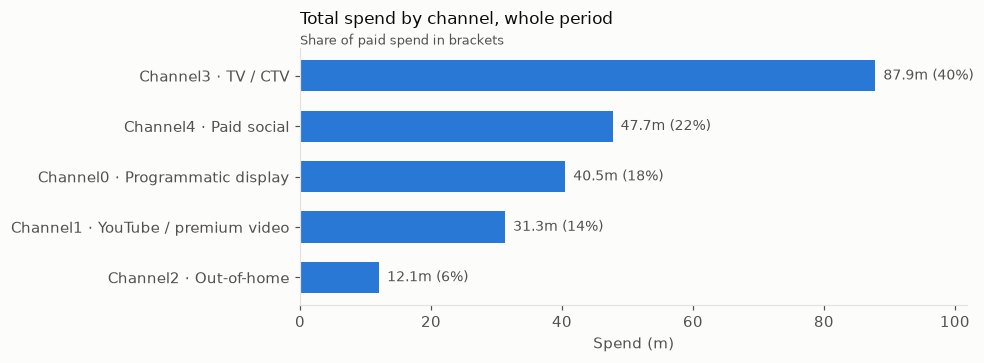

Channel3_spend    40.0
Channel4_spend    21.7
Channel0_spend    18.5
Channel1_spend    14.3
Channel2_spend     5.5 

total paid spend : 219,492,402
total revenue    : 1,318,718,006
spend / revenue  : 16.6%


In [4]:
tot = df[SPEND].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.barh([LABEL(c.replace("_spend","")) for c in tot.index][::-1], (tot/1e6).values[::-1], color=BLUE, height=.62)
for i, v in enumerate((tot/1e6).values[::-1]):
    ax.text(v, i, f"  {v:,.1f}m ({v/(tot.sum()/1e6)*100:.0f}%)", va="center", fontsize=9, color=INK2)
ax.set_xlim(0, (tot/1e6).max()*1.16)
ax.grid(axis="y", visible=False)
tidy(ax, "Total spend by channel, whole period", "Share of paid spend in brackets", "")
ax.set_xlabel("Spend (m)"); plt.tight_layout(); plt.show()

print((tot/tot.sum()).mul(100).round(1).to_string(), "\n")
print(f"total paid spend : {tot.sum():,.0f}")
print(f"total revenue    : {df.revenue.sum():,.0f}")
print(f"spend / revenue  : {tot.sum()/df.revenue.sum():.1%}")

#### What to look for

- How concentrated is the budget? A channel at a few percent of spend may simply lack the leverage to be estimated with any precision — and a confident ROI on it would be a red flag, not a finding.
- Is the spend/revenue ratio plausible? Compare it against what you'd expect for the kind of advertiser this is meant to represent.
- Which channels are large enough that moving money in or out would actually change the business? Those are the ones your recommendation lives or dies on.
- Remember the channels are anonymous here. Does the spend pattern hint at what media type each one is — and would you be willing to defend that guess in an interview?

#### Reference

- [Meridian — collecting data](https://developers.google.com/meridian/docs/user-guide/collect-data)
- [Meridian demo — ROI, marginal ROI and response curves](https://github.com/google/meridian/blob/main/demo/ROI_mROI_Response_Curves.ipynb)

#### Claude's first pass — *anchors to argue with, not answers*

- Concentrated: **C3 TV alone is 40% of paid spend**; C2 OOH is 5.5%.
- Spend/revenue 16.6% — heavy, more DTC than mature CPG.
- C2 is small enough that any ROI on it will carry wide intervals. Worth deciding now what you'll say if it comes back looking like the best channel.

**Your read:**



## 4. What does each channel's spend look like week to week?

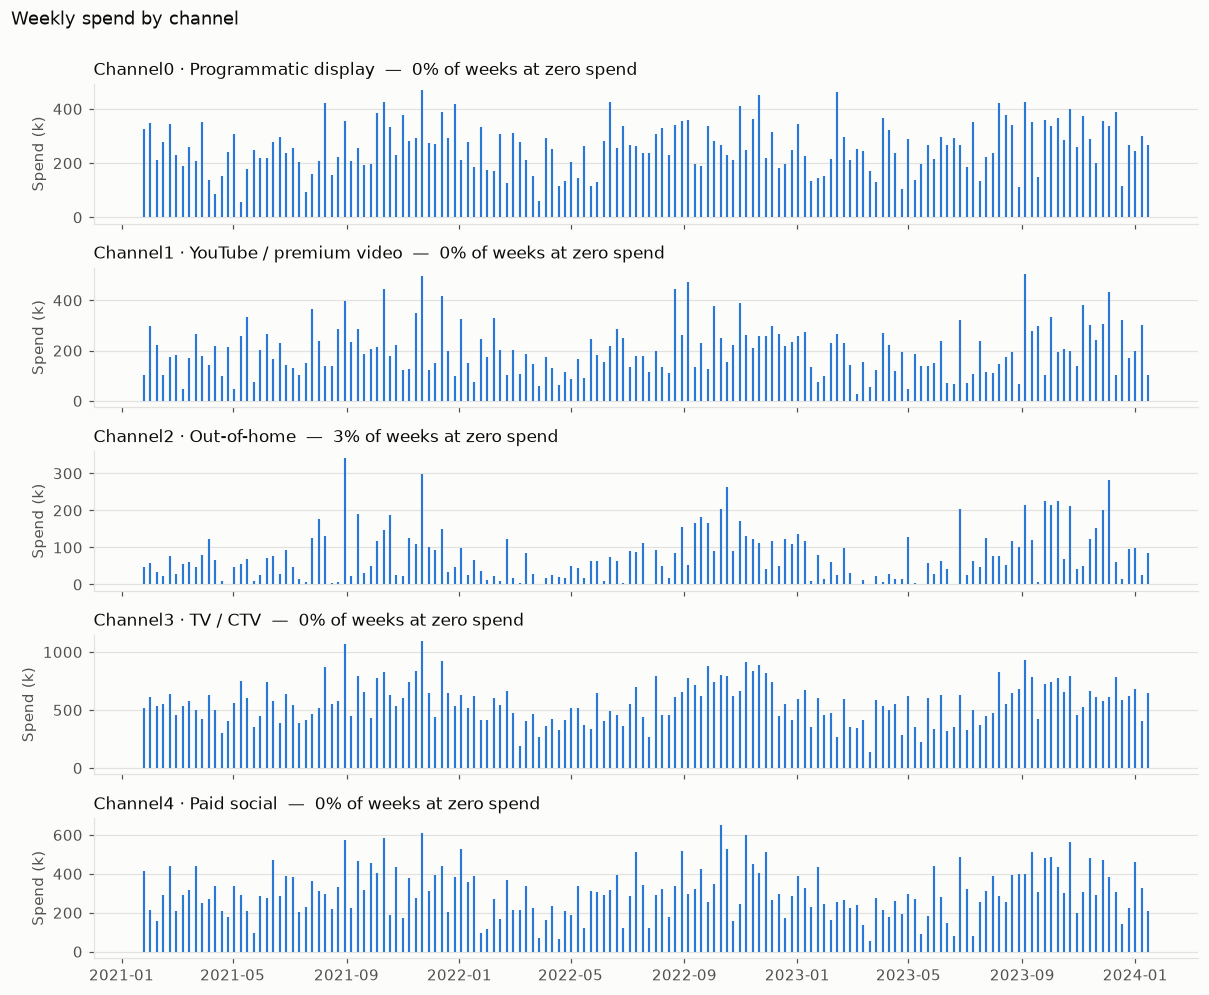

In [5]:
fig, axes = plt.subplots(5, 1, figsize=(11, 9), sharex=True)
for ax, c in zip(axes, CH):
    s = df[f"{c}_spend"]/1e3
    ax.vlines(df.time, 0, s, color=BLUE, linewidth=1.4)
    tidy(ax, f"{LABEL(c)}  —  {(s==0).mean():.0%} of weeks at zero spend", ylab="Spend (k)")
axes[-1].set_xlabel("")
fig.suptitle("Weekly spend by channel", x=0.005, ha="left", y=1.0, fontsize=12)
plt.tight_layout(); plt.show()

#### What to look for

- Which channels are always-on and which are flighted? They are identified very differently — a channel that never turns off gives you almost nothing to learn decay from.
- Do the bursts repeat seasonally? If a channel only ever runs in peak weeks, its effect and seasonality are entangled and may not be separable at all.
- Look for long dark stretches. Those are where you can actually *watch* an effect decay, and they're what makes adstock estimable.
- Does any channel change regime — ramps up partway through and stays there? A regime change breaks the assumption that response is stable across the window.
- Does the flighting look like a media plan a human would buy, or like a random number generator? Your answer bears on how much the findings can be said to transfer.

#### Reference

- [Robyn — adstock and saturation features](https://facebookexperimental.github.io/Robyn/docs/features)
- [Meridian — model specification](https://developers.google.com/meridian/docs/basics/model-spec)

#### Claude's first pass — *anchors to argue with, not answers*

- **Only C2 OOH ever goes dark, and only in 2.6% of weeks.** The other four are always-on.
- That matters more than it looks: with no on/off cycling, there is little for a carryover parameter to latch onto. Adstock will be weakly identified almost everywhere.

**Your read:**



## 5. Is there enough variation to identify an effect?

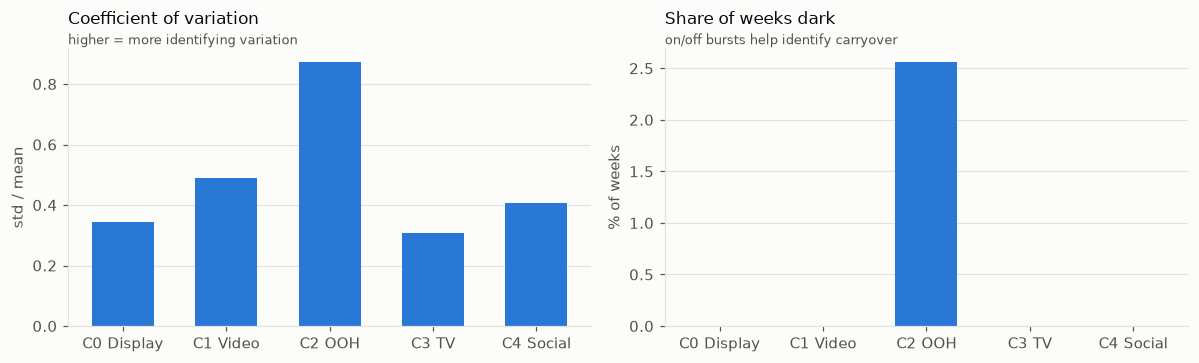

               cv  zero_weeks  p10_p90_ratio
C0 Display  0.343       0.000          2.725
C1 Video    0.490       0.000          3.451
C2 OOH      0.874       0.026         20.336
C3 TV       0.308       0.000          2.257
C4 Social   0.408       0.000          3.042


In [6]:
v = pd.DataFrame({
    "cv": df[SPEND].std()/df[SPEND].mean(),
    "zero_weeks": (df[SPEND]==0).mean(),
    "p10_p90_ratio": df[SPEND].quantile(.9)/df[SPEND].quantile(.1).replace(0, np.nan),
})
v.index = [SHORT[i.replace("_spend","")] for i in v.index]

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].bar(v.index, v.cv, color=BLUE, width=.6)
tidy(ax[0], "Coefficient of variation", "higher = more identifying variation", "std / mean")
ax[1].bar(v.index, v.zero_weeks*100, color=BLUE, width=.6)
tidy(ax[1], "Share of weeks dark", "on/off bursts help identify carryover", "% of weeks")
for a in ax: a.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()
print(v.round(3).to_string())

#### What to look for

- Which channel has the least variation? That one will come back with the widest uncertainty, and it should.
- Is the variation genuine on/off cycling, or a handful of spikes? A few spikes means a few observations are carrying the entire estimate.
- The blunt test: **would you be comfortable quoting an ROI for a channel that barely moved?** If not, decide now what you'll say about it rather than after the model gives you a number.
- Low variation and high collinearity compound each other. Hold this alongside section 6 rather than reading them separately.

#### Reference

- [Chan & Perry — Challenges and Opportunities in Media Mix Modeling](https://research.google/pubs/challenges-and-opportunities-in-media-mix-modeling/)
- [Open-Source Media and Marketing Mix Modeling — practice-oriented overview](https://link.springer.com/article/10.1007/s40547-026-00161-4)

#### Claude's first pass — *anchors to argue with, not answers*

- **The smallest channel has the most variation** — C2 OOH: CV 0.87, p90/p10 = 20.3.
- **The largest has the least** — C3 TV: CV 0.31, p90/p10 = 2.26, at 40% of budget.
- That inversion is the central tension: the channel whose budget decision matters most is the one the data can say least about.

**Your read:**



## 6. Are the channels collinear?

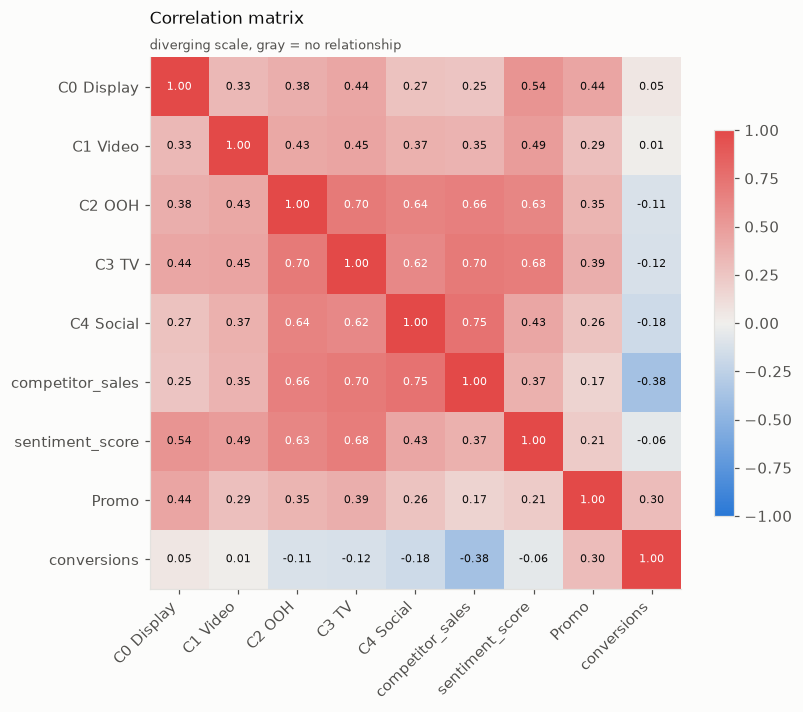

strongest channel-to-channel pair: ('C2 OOH', 'C3 TV') r = 0.700


In [7]:
cols = SPEND + ["competitor_sales_control", "sentiment_score_control", "Promo", "conversions"]
cm = df[cols].corr()
cm.index = cm.columns = [SHORT.get(c.replace("_spend",""), c.replace("_spend","").replace("_control","")) for c in cols]

fig, ax = plt.subplots(figsize=(7.6, 6.4))
im = ax.imshow(cm, cmap=DIVERGING, vmin=-1, vmax=1)
ax.set_xticks(range(len(cm))); ax.set_xticklabels(cm.columns, rotation=45, ha="right")
ax.set_yticks(range(len(cm))); ax.set_yticklabels(cm.index)
for i in range(len(cm)):
    for j in range(len(cm)):
        ax.text(j, i, f"{cm.iloc[i,j]:.2f}", ha="center", va="center", fontsize=7.5,
                color=INK if abs(cm.iloc[i,j]) < .55 else "#ffffff")
ax.grid(False)
tidy(ax, "Correlation matrix", "diverging scale, gray = no relationship", pad=22)
fig.colorbar(im, ax=ax, shrink=.72)
plt.tight_layout(); plt.show()

off = cm.loc[[SHORT[c.replace("_spend","")] for c in SPEND], [SHORT[c.replace("_spend","")] for c in SPEND]]
off = off.where(~np.eye(len(off), dtype=bool)).abs().stack()
print(f"strongest channel-to-channel pair: {off.idxmax()} r = {off.max():.3f}")

#### What to look for

- Which channel pairs are strongly related? When two channels move together, the data cannot tell you which one did the work — the *sum* is estimable, the split is not.
- Does any channel correlate with a **control**? That's worse than channel-to-channel, because the control is not something you can reallocate.
- Look at the bottom row. Are the raw channel-to-outcome correlations near zero? If so, what does that imply about how much work the model has to do — and would a naive analyst have concluded media doesn't work?
- Correlation is pairwise. Several channels can be jointly collinear without any single pair looking bad. What would you need to compute to detect that?

#### Reference

- [Multicollinearity — what it does to coefficient estimates](https://en.wikipedia.org/wiki/Multicollinearity)
- [Chan & Perry — Challenges and Opportunities in Media Mix Modeling](https://research.google/pubs/challenges-and-opportunities-in-media-mix-modeling/)

#### Claude's first pass — *anchors to argue with, not answers*

- Strongest channel pair is **C2 OOH ↔ C3 TV at 0.70**.
- **But the worse problem is with a control:** C4 Social ↔ competitor_sales is **0.75**, C3 TV ↔ competitor_sales is 0.70. Media is more entangled with the control than with other media.
- Bottom row: every raw media-to-conversions correlation sits between −0.18 and +0.05. A naive analyst reading this chart alone would conclude media does nothing.

**Your read:**



## 7. Do the controls behave, or does something dominate the outcome?

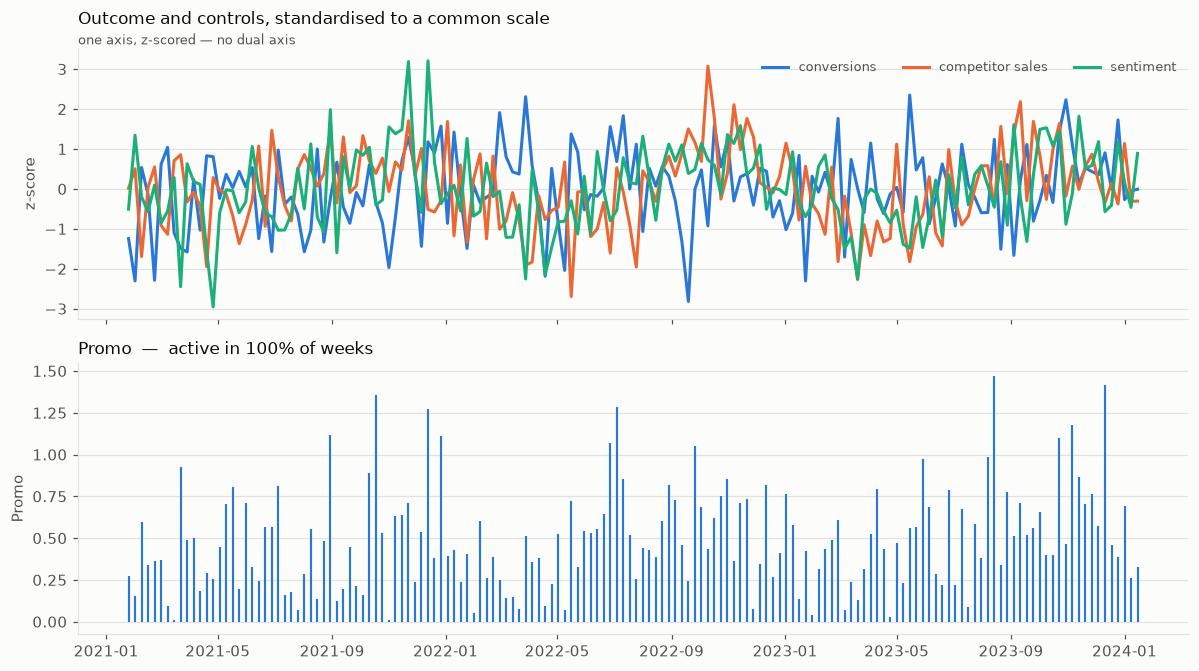

competitor_sales_control   -0.380
sentiment_score_control    -0.056
Promo                       0.299
Channel0_spend              0.051
Channel1_spend              0.012
Channel2_spend             -0.110
Channel3_spend             -0.124
Channel4_spend             -0.179


In [8]:
z = lambda s: (s - s.mean())/s.std()
fig, ax = plt.subplots(2, 1, figsize=(11, 6.2), sharex=True)

ax[0].plot(df.time, z(df.conversions), color=BLUE, label="conversions")
ax[0].plot(df.time, z(df.competitor_sales_control), color=ORANGE, label="competitor sales")
ax[0].plot(df.time, z(df.sentiment_score_control), color=AQUA, label="sentiment")
ax[0].legend(frameon=False, fontsize=8.5, ncol=3, labelcolor=INK2)
tidy(ax[0], "Outcome and controls, standardised to a common scale",
     "one axis, z-scored — no dual axis", "z-score")

ax[1].vlines(df.time, 0, df.Promo, color=BLUE, linewidth=1.4)
tidy(ax[1], f"Promo  —  active in {(df.Promo>0).mean():.0%} of weeks", ylab="Promo")
plt.tight_layout(); plt.show()

print(df[CONTROL + SPEND].corrwith(df.conversions).round(3).to_string())

#### What to look for

- Does any control track the outcome closely enough to absorb most of its variance? If so, media gets estimated off whatever is left over, and the ROIs come back small for a reason that has nothing to do with media.
- **Is anything here actually a mediator rather than a control?** If media influences it, and you control for it, you delete part of the effect you're trying to measure. This is the single most common way a well-intentioned control ruins an MMM.
- Is `Promo` a control or a channel? It has a budget owner and a spend implication — so whose lever is it, and should a reallocation be allowed to touch it?
- Sentiment: is it a cause of conversions, a consequence of them, or both? Write down which, because the model can't tell and will assume you were right.

#### Reference

- [Chan & Perry — Challenges and Opportunities in Media Mix Modeling](https://research.google/pubs/challenges-and-opportunities-in-media-mix-modeling/)
- [Meridian — configuring the model](https://developers.google.com/meridian/docs/user-guide/configure-model)

#### Claude's first pass — *anchors to argue with, not answers*

- `competitor_sales_control` is the strongest single relationship with conversions (−0.38) — but it correlates 0.70–0.75 with media, so it is not an independent control.
- `Promo` correlates +0.30 with conversions **and 0.45 with total media spend.** Whose lever is it?
- `sentiment_score_control` is −0.06 with conversions. It may earn no place in the model at all.

**Your read:**



## 8. Is there visible carryover?
Correlation of each channel's spend at lag *k* with conversions today.
A peak at k>0, or a slow decay, is a hint that adstock is warranted.

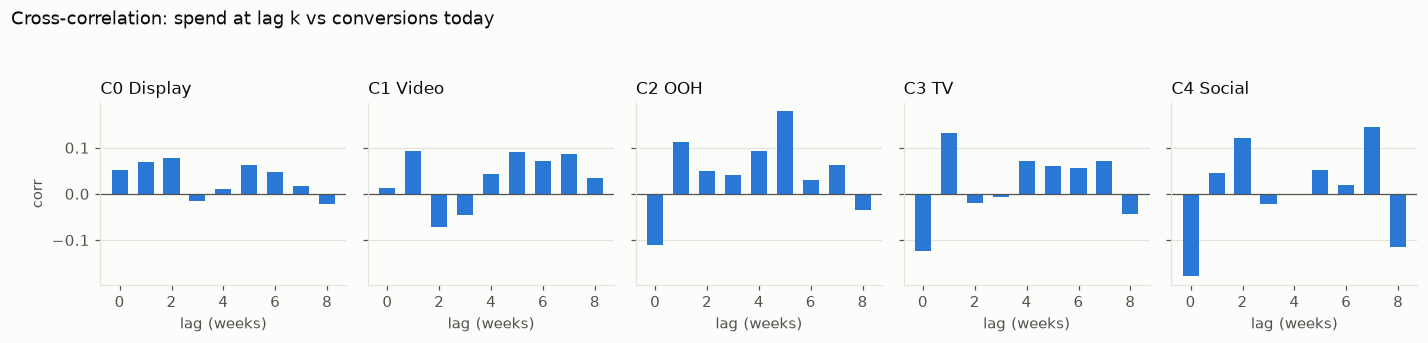

In [9]:
LAGS = range(0, 9)
fig, axes = plt.subplots(1, 5, figsize=(13, 2.9), sharey=True)
for ax, c in zip(axes, CH):
    r = [df[f"{c}_spend"].shift(k).corr(df.conversions) for k in LAGS]
    ax.bar(list(LAGS), r, color=BLUE, width=.62)
    ax.axhline(0, color=INK2, linewidth=.8)
    tidy(ax, SHORT[c], ylab="corr" if c == "Channel0" else None)
    ax.set_xlabel("lag (weeks)"); ax.grid(axis="x", visible=False)
fig.suptitle("Cross-correlation: spend at lag k vs conversions today",
             x=0.005, ha="left", y=1.06, fontsize=12)
plt.tight_layout(); plt.show()

#### What to look for

- Does correlation peak at lag 0, or later? A later peak is a hint — not proof — that the effect takes time to land.
- Does it decay smoothly, or jump around? Smooth decay is consistent with adstock. Jumping around is usually noise wearing a costume.
- **The trap:** this is raw correlation with nothing controlled for. If both spend and conversions are seasonal, you will see a lag pattern that is pure seasonality. What would you need to do to rule that out before believing any of these shapes?
- How many weeks of carryover would you consider *plausible* for each media type, before looking? Writing that down first stops you from rationalising whatever the chart shows.

#### Reference

- [Jin et al. — Bayesian Methods for Media Mix Modeling with Carryover and Shape Effects](https://research.google/pubs/bayesian-methods-for-media-mix-modeling-with-carryover-and-shape-effects/)
- [Robyn — adstock and saturation features](https://facebookexperimental.github.io/Robyn/docs/features)

#### Claude's first pass — *anchors to argue with, not answers*

- **No visible carryover anywhere.** Every cross-correlation across every channel and lag sits within |r| ≤ 0.18.
- Peak lags are scattered (0, 1, 1, 2, 5) with no decay shape — that pattern is what noise looks like, not adstock.
- **Careful:** absence here is not evidence of absence. Raw uncontrolled correlation is a weak instrument, and section 4 already told us the always-on channels give it little to work with.

**Your read:**



## 9. Is there visible diminishing returns?
Weeks binned by spend level; the dot is mean conversions in that bin.
A flattening at the right-hand end is the saturation the model is meant to find.

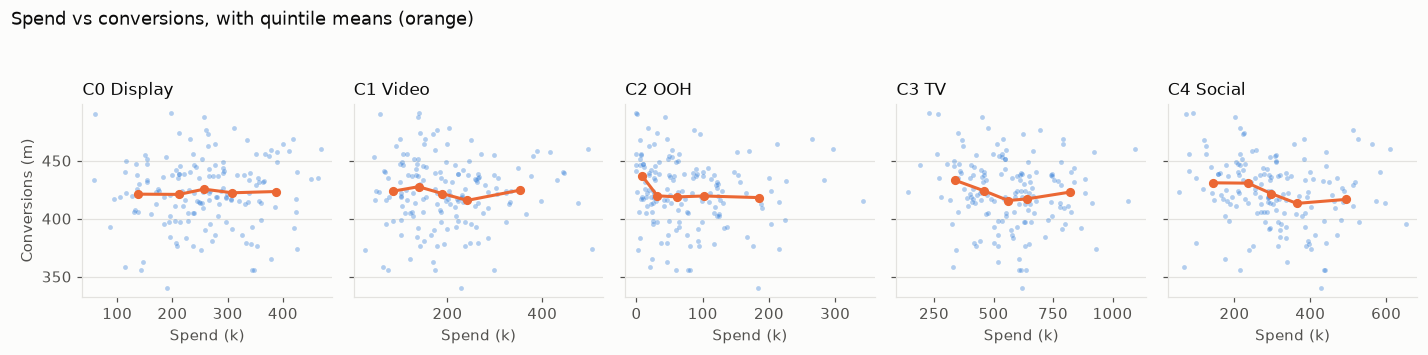

In [10]:
fig, axes = plt.subplots(1, 5, figsize=(13, 3.0), sharey=True)
for ax, c in zip(axes, CH):
    s = df[f"{c}_spend"]
    ax.scatter(s/1e3, df.conversions/1e6, s=10, color=BLUE, alpha=.35, linewidths=0)
    q = pd.qcut(s, 5, duplicates="drop")
    b = df.groupby(q, observed=True).agg(x=(f"{c}_spend","mean"), y=("conversions","mean"))
    ax.plot(b.x/1e3, b.y/1e6, color=ORANGE, marker="o", markersize=5)
    tidy(ax, SHORT[c], ylab="Conversions (m)" if c == "Channel0" else None)
    ax.set_xlabel("Spend (k)")
fig.suptitle("Spend vs conversions, with quintile means (orange)",
             x=0.005, ha="left", y=1.06, fontsize=12)
plt.tight_layout(); plt.show()

#### What to look for

- Does the quintile line bend over at the top, stay straight, or slope down?
- **The trap:** this is bivariate and uncontrolled. High-spend weeks may also be high-season weeks, or weeks when a promo ran. Does any shape you see survive that suspicion?
- If a line slopes *downward*, resist reading it as 'this channel hurts sales'. What does it more likely say about **when** the planner chose to spend?
- This is the closest thing here to a preview of your actual deliverable — the saturation curve. If you can't see a bend now, what would it mean if the model produces a confident one later?

#### Reference

- [Jin et al. — Bayesian Methods for Media Mix Modeling with Carryover and Shape Effects](https://research.google/pubs/bayesian-methods-for-media-mix-modeling-with-carryover-and-shape-effects/)
- [Meridian demo — ROI, marginal ROI and response curves](https://github.com/google/meridian/blob/main/demo/ROI_mROI_Response_Curves.ipynb)

#### Claude's first pass — *anchors to argue with, not answers*

- **No saturation bend is visible in any channel.** The quintile lines are close to flat.
- Three of five slope *downward*: C2 −18m, C4 −14m, C3 −10m from lowest to highest spend quintile.
- Read that as **when the planner spent**, not as media hurting sales. It is the classic confound this chart cannot resolve.

**Your read:**



## 10. Are spend and impressions consistent?

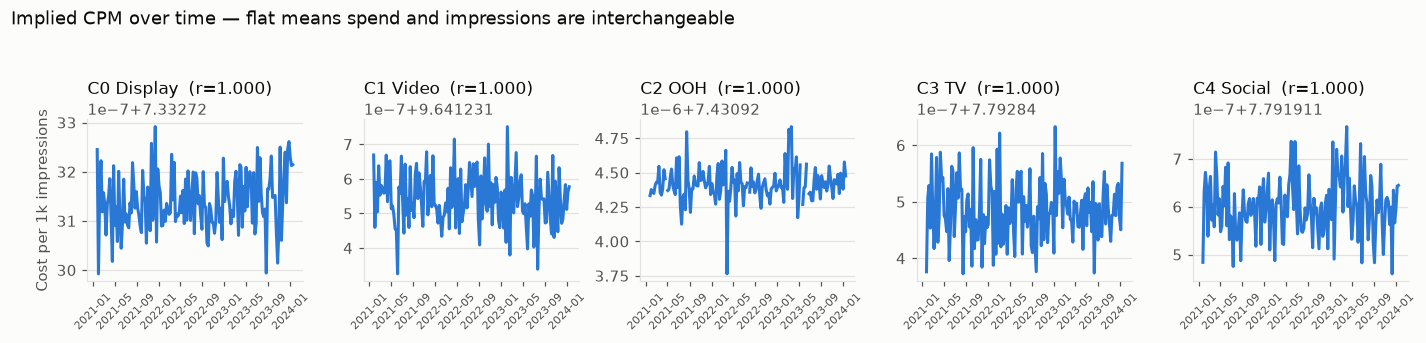

In [11]:
fig, axes = plt.subplots(1, 5, figsize=(13, 2.9), sharex=True)
for ax, c in zip(axes, CH):
    cpm = (df[f"{c}_spend"] / df[f"{c}_impression"].replace(0, np.nan)) * 1000
    ax.plot(df.time, cpm, color=BLUE)
    tidy(ax, f"{SHORT[c]}  (r={df[f'{c}_spend'].corr(df[f'{c}_impression']):.3f})",
         ylab="Cost per 1k impressions" if c == "Channel0" else None)
    ax.tick_params(axis="x", labelrotation=45, labelsize=7)
fig.suptitle("Implied CPM over time — flat means spend and impressions are interchangeable",
             x=0.005, ha="left", y=1.06, fontsize=12)
plt.tight_layout(); plt.show()

#### What to look for

- Is CPM flat, drifting, or jumpy? Flat means spend and impressions carry identical information and the choice between them is free.
- If CPM drifts, the choice matters: **spend measures what it cost, impressions measure what was delivered.** Media effects come from delivery; budget decisions are made in money. Which unit belongs on which side of your model?
- Rising CPM over time would be a real-world signal of auction pressure or audience exhaustion. Does anything like that appear here — and if not, what does that tell you about the simulation?
- Whichever unit you choose, you'll need the other one to convert a modelled effect back into a budget recommendation. Note now how you'd do that.

#### Reference

- [Meridian — collecting data](https://developers.google.com/meridian/docs/user-guide/collect-data)
- [Meridian — loading national data](https://developers.google.com/meridian/docs/user-guide/load-national-data)

#### Claude's first pass — *anchors to argue with, not answers*

- **CPM is exactly constant per channel** (7.3327 / 9.6412 / 7.4309 / 7.7928 / 7.7919) to floating-point noise.
- So spend and impressions are the same variable in different units — no auction pressure, no audience exhaustion, no seasonal CPM. Real data never looks like this.
- The unit choice is therefore free. But note what it costs the story: nothing here can show rising media costs over time.

**Your read:**



---
## Where this leaves us

Fill in once the sections above are worked through. Anything that turns into a
project decision goes into `DECISIONS.md` — not here.

**Questions this raised that the data can't answer:**

**Things to check before modeling:**

---

### Further reading

**The two papers behind most MMM practice**
- [Jin et al. — Bayesian Methods for MMM with Carryover and Shape Effects](https://research.google/pubs/bayesian-methods-for-media-mix-modeling-with-carryover-and-shape-effects/) — where adstock and Hill saturation come from
- [Chan & Perry — Challenges and Opportunities in Media Mix Modeling](https://research.google/pubs/challenges-and-opportunities-in-media-mix-modeling/) — the honest account of what MMM can and cannot identify. Read this one before defending any result.

**Where the field is now**
- [Open-Source Media and Marketing Mix Modeling — practice-oriented overview](https://link.springer.com/article/10.1007/s40547-026-00161-4)
- [Packaging Up Media Mix Modeling (arXiv)](https://arxiv.org/abs/2403.14674)
- [Estimating Ad Effectiveness Using Geo Experiments](https://research.google/pubs/estimating-ad-effectiveness-using-geo-experiments-in-a-time-based-regression-framework/) — relevant to the Phase 5 geo step

**Tooling**
- [Meridian docs](https://developers.google.com/meridian) · [model specification](https://developers.google.com/meridian/docs/basics/model-spec) · [getting-started notebook](https://github.com/google/meridian/blob/main/demo/Meridian_Getting_Started.ipynb)
- [Robyn — adstock and saturation](https://facebookexperimental.github.io/Robyn/docs/features) — different framework, same concepts, often explained more plainly
- [PyMC-Marketing MMM example](https://www.pymc-marketing.io/en/stable/notebooks/mmm/mmm_example.html)